# Discovery of the Higgs Boson

Final Project, Probability and Statistics for Data Analysis

On July 4, 2012, the ATLAS and CMS experiments at the LHC announced a new
particle consistent with the Standard Model Higgs boson. This notebook hands you
real CMS four-lepton events from that era, about half the data the four-lepton
channel had at the announcement, plus the tools of this course: a classifier as
a likelihood-ratio approximation, a generalized likelihood-ratio test with a
nuisance parameter, toy p-values, goodness-of-fit, and a power calculation. The
question the project answers is the one the experiments faced: what are you
entitled to claim from this data?

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

Before running anything, write down what you expect. Will half the
announcement-era data in a single channel show the particle? At what
significance, if any?

Two through-lines from Module 5 carry over, and both get sharper teeth here.
First, significant is not adequate: a test verdict is only as good as the model
it tests against. Second, rejecting the null is not confirming your alternative.

The work runs in two threads. Sections 2 and 3 turn a classifier into a test
statistic. Sections 4 through 7 set the classifier aside and run the discovery
test itself on the mass spectrum, then ask how solid it is and what more data
would buy. Section 8 returns to the classifiers and measures what the analysis
gains from them. Section 9 settles the opening question, and its checkpoint is
graded before you submit.

Run with the seed set below. The heavy lifting lives in the tested modules
`util.py` and `higgs_analysis.py` beside this notebook, so every cell here stays
short and readable. The scientific result (Sections 4 to 6) does not depend on
which classifier you build.


## 0. Setup: run this cell first

If you opened this notebook standalone (for example from the Colab badge), the
helper modules and data files are not in your session yet. This cell fetches
them from the project repository. Run locally from a full checkout and it does
nothing.


In [1]:
# Colab bootstrap: fetch helper modules and data if they aren't already here.
import os, urllib.request

REF = "main"   # pin to a release tag or commit SHA before the offering opens
REPO = f"https://raw.githubusercontent.com/codey-m/prob_stats/{REF}/final_project"
NEEDED = [
    "util.py", "higgs_analysis.py",
    "data/MC/higgs2012.csv", "data/MC/zzto4mu2012.csv",
    "data/MC/zzto2mu2e2012.csv", "data/MC/zzto4e2012.csv",
    "data/data/clean_data_2012.csv",
]
for rel in NEEDED:
    if not os.path.exists(rel):
        folder = os.path.dirname(rel)
        if folder:
            os.makedirs(folder, exist_ok=True)
        urllib.request.urlretrieve(f"{REPO}/{rel}", rel)
        print(f"downloaded {rel}")
print("environment ready")


environment ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

import util
import higgs_analysis as H

# SEED fixes the toys, the MLP's initialization, and (because sklearn's MLP
# takes no sample weights) which rows are resampled into its training set.
# The train/holdout split is pinned separately at seed 0 in H.prepare below,
# so the holdout is identical across runs and across students.
SEED = 6372
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (7, 4)


## 1. The data and the simulation

Two ingredients.

Experimental data: about 495 real CMS events that survived the H→ZZ→4ℓ
selection. Each event is four leptons (electrons or muons), described by their
four-momenta $(E, p_x, p_y, p_z)$ plus reconstructed masses.

Monte Carlo simulation (MC): labeled events for the Higgs signal and for the
three ZZ→4ℓ background processes (`zz4mu`, `zz2mu2e`, `zz4e`), which produce
the same four-lepton signature as the signal.

Two further backgrounds, Drell-Yan and $t\bar t$, are not included. Their
combined yield (about 10 events) is comparable to the signal itself, but the
available simulation keeps only a handful of rows for them, too few to model a
mass shape, and resampling those rows would repeat information rather than add
it. Nothing downstream models them or corrects for them. Treat that as a stated
limitation on every number this project reports; Section 9 returns to it.

Each MC process carries a physical weight, the number of expected events one
simulated row represents. Summing weights gives a process's expected yield. The
next cell tallies them against the observed count.


In [3]:
st = H.prepare(seed=0)
data = st["data"]
weights = util.compute_weights()

print(f"experimental events: {len(data)}")
print("MC process yields (expected events at this luminosity):")
for name, p, w in zip(util.PROCESS_NAMES, st["processes"], weights):
    print(f"  {name:9s}: {len(p):6d} rows  ->  yield {w*len(p):8.2f}")
tot_bkg = sum(w*len(p) for w, p in zip(weights[1:], st["processes"][1:]))
print(f"\ntotal expected background: {tot_bkg:.1f}")
print(f"total expected signal:     {weights[0]*len(st['processes'][0]):.1f}")
print(f"observed:                  {len(data)}   (data/prediction = "
      f"{len(data)/(tot_bkg+weights[0]*len(st['processes'][0])):.3f})")


experimental events: 495
MC process yields (expected events at this luminosity):
  higgs    :   9348 rows  ->  yield     9.38
  zz4mu    :  41106 rows  ->  yield   135.91
  zz2mu2e  :  26537 rows  ->  yield   204.39
  zz4e     :  21476 rows  ->  yield    71.00

total expected background: 411.3
total expected signal:     9.4
observed:                  495   (data/prediction = 1.177)


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

The signal is tiny: about 9 expected Higgs events on 411 expected background.
And the data run 18 percent above the total prediction, so the simulation's
normalization is off. Section 4 has to absorb that mismatch before any test of
"is there a Higgs" can be trusted.


## 2. Weighting for the Neyman-Pearson connection

The most powerful test of background $P_0$ against signal $Q$ uses the
log-likelihood ratio $h^*(x) = \log\big(Q(x)/P_0(x)\big)$. That is the
Neyman-Pearson lemma. We do not know $P_0$ or $Q$ in closed form, only samples
from each, but a classifier trained with cross-entropy has log-odds that
converge to $h^*$ plus a constant $\log(\nu_1/\nu_0)$ set by the class
proportions. Giving both classes equal total weight makes the constant zero, so
the trained log-odds read as $h^*$ directly.

A classifier's last layer computes a real number $z(x)$ and passes it through
the sigmoid, $f = e^z/(1 + e^z)$. Then $1 - f = 1/(1 + e^z)$, so

$$\log\big(f/(1-f)\big) = \log\big(e^z\big) = z.$$

The log-odds is not something you compute from the classifier's output. It is
the number the classifier already had, one step before the sigmoid. That is why
`score()` reads `decision_function` where a model exposes it and recovers
`log(p/(1-p))` where it does not: the two are the same quantity.

The offset $\log(\nu_1/\nu_0)$ is not a formality. Train on the physical
weights instead, where the signal yield is 9.38 against 411.30 of background,
and the offset is $\log(9.38/411.30) = -3.78$. A threshold at $z = 0$ would
then sit at $h^* = 3.78$, a likelihood ratio near 44, not the even-odds cut it
looks like.

This balancing is a convenience, not a requirement. The constant is the same
for every event, so it moves every score by the same amount and changes no
ranking, no AUC, and none of the score bins built from quantiles in Section 8.
We balance so that log-odds are readable on an absolute scale and a fixed
threshold means the same thing across models.

`compute_weights()` returns the physical weights, and `class_balanced_weights()`
rescales them to equal class totals for training. The check below confirms the
balance, and then we train.


In [4]:
full = st["train"]
sig = (full["_proc"] == 0).values
bal = util.class_balanced_weights(sig, full["_w"].values)
print(f"total signal weight     : {bal[sig].sum():.1f}")
print(f"total background weight  : {bal[~sig].sum():.1f}")
print(f"ratio (should be 1.000)  : {bal[sig].sum()/bal[~sig].sum():.3f}")


total signal weight     : 34462.5
total background weight  : 34462.5
ratio (should be 1.000)  : 1.000


## 3. A test statistic from a classifier

We hand the classifier only per-lepton kinematics, 24 numbers per event
(energy, the three momentum components, and the angles `eta` and `phi`, for
each of the four leptons), and withhold the reconstructed masses. The model has to find
the structure itself. Start with logistic regression, the Unit 1 model.

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

A weighted AUC of 0.5 is chance and 1.0 is perfect separation. Where
does a linear model on these 24 numbers land? Write your number down.


linear logistic regression, weighted AUC = 0.632


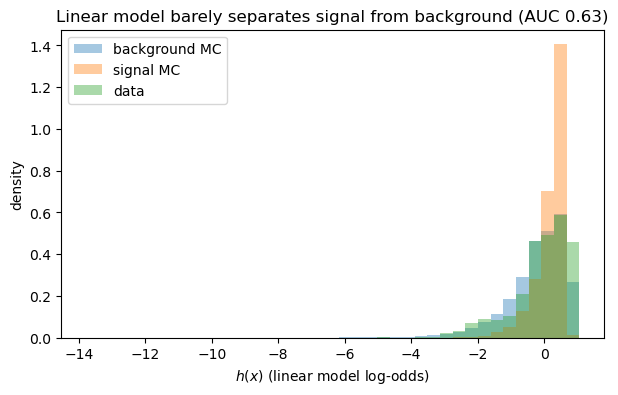

In [5]:
lin, featfn = H.make_classifier("linear", st["train"])
auc_lin = H.auc(lin, featfn, st["holdout"])
print(f"linear logistic regression, weighted AUC = {auc_lin:.3f}")

# distributions of h(x) for signal MC, background MC, and real data
h_sig  = H.score(lin, featfn, st["processes"][0])
h_bkg  = np.concatenate([H.score(lin, featfn, p) for p in st["processes"][1:]])
h_data = H.score(lin, featfn, data)
bins = np.linspace(min(h_bkg.min(), h_data.min()), max(h_sig.max(), h_data.max()), 40)
plt.hist(h_bkg,  bins=bins, density=True, alpha=0.4, label="background MC")
plt.hist(h_sig,  bins=bins, density=True, alpha=0.4, label="signal MC")
plt.hist(h_data, bins=bins, density=True, alpha=0.4, label="data")
plt.xlabel(r"$h(x)$ (linear model log-odds)"); plt.ylabel("density"); plt.legend()
plt.title(f"Linear model barely separates signal from background (AUC {auc_lin:.2f})")
plt.show()


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

AUC 0.63. Barely better than chance. Is the Higgs simply not separable from the
ZZ background? No. The discriminating variable is the four-lepton invariant
mass, and there is a structural reason a linear model cannot see it:

$$ m^2 = \Big(\textstyle\sum_i E_i\Big)^2 - \Big(\sum_i p_{x,i}\Big)^2
        - \Big(\sum_i p_{y,i}\Big)^2 - \Big(\sum_i p_{z,i}\Big)^2 $$

The mass is a quadratic form in the raw inputs, and no linear function can
represent it. Don't take that on faith: the next cell checks the identity
numerically against the provided mass column.


In [6]:
d = data
E  = d[["E1","E2","E3","E4"]].values.sum(1)
px = d[["px1","px2","px3","px4"]].values.sum(1)
py = d[["py1","py2","py3","py4"]].values.sum(1)
pz = d[["pz1","pz2","pz3","pz4"]].values.sum(1)
m_reconstructed = np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))
print(f"max |reconstructed mass - provided mass| = "
      f"{np.abs(m_reconstructed - d['mass'].values).max():.2e} GeV")
print("=> the target is a quadratic form in the inputs; a linear model cannot represent it.")


max |reconstructed mass - provided mass| = 5.61e-07 GeV
=> the target is a quadratic form in the inputs; a linear model cannot represent it.


So give the model the capacity to form products of inputs. Two routes: a
quadratic feature expansion on the raw inputs, which can represent $m^2$
exactly while staying inside Unit 1 machinery, or a small neural network, which
has to approximate it from the raw inputs on its own.


In [7]:
quad, _ = H.make_classifier("quadratic", st["train"])
mlp,  _ = H.make_classifier("mlp", st["train"])
print("weighted AUC on the held-out MC (mass-blind raw inputs):")
print(f"  linear                       {H.auc(lin,  featfn, st['holdout']):.3f}")
print(f"  quadratic feature expansion  {H.auc(quad, featfn, st['holdout']):.3f}")
print(f"  3-layer neural net           {H.auc(mlp,  featfn, st['holdout']):.3f}")


weighted AUC on the held-out MC (mass-blind raw inputs):
  linear                       0.632
  quadratic feature expansion  0.906
  3-layer neural net           0.961


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

From 0.63 to 0.91 with quadratic features, and 0.96 with the neural net. Same
raw inputs, now with the capacity to build the mass. The net rediscovered, from
four-momenta alone, the variable physicists spent years learning to construct;
that is the result of Baldi, Sadowski and Whiteson (2014). Hold on to the AUC
ordering. Section 8 tests whether it means what it appears to mean.


## 4. The discovery test: a mass fit with a floating background

A classifier that separates simulated signal from simulated background is not
yet evidence for a particle. Section 1 left the data 18 percent above the
prediction, so a naive data-versus-simulation test would reject the null
because the normalization is wrong, not because a Higgs exists.

The fix is the generalized likelihood-ratio test from Lecture 5. Bin the events
in mass over 100-200 GeV and model the expected count in bin $i$ as

$$ \lambda_i = \mu\, S_i + \kappa\, B_i $$

where $S_i$ and $B_i$ are the signal and background templates from MC, $\mu$ is
the signal strength ($\mu=0$ means no Higgs, $\mu=1$ the Standard Model rate),
and $\kappa$ is a free background normalization, a nuisance parameter. Letting
$\kappa$ float absorbs an overall mis-normalization. We test $H_0:\mu=0$ with
$q = 2\log\frac{\max_{\mu,\kappa}L}{\max_\kappa L|_{\mu=0}}$.

Of the 495 events, 137 fall in the fit window. The classifier plays no part in
this section.

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

Given the excess of data over prediction and a possible peak near 125
GeV, where does $\hat\mu$ land, and how many sigma is the excess? Commit to
both numbers before running the fit.


events in the 100-200 GeV fit window: 137 of 495
mu_hat    (signal strength)      = 1.103
kappa_hat (background scale)      = 1.298
test statistic q                 = 5.247
asymptotic significance sqrt(q)   = 2.29 sigma


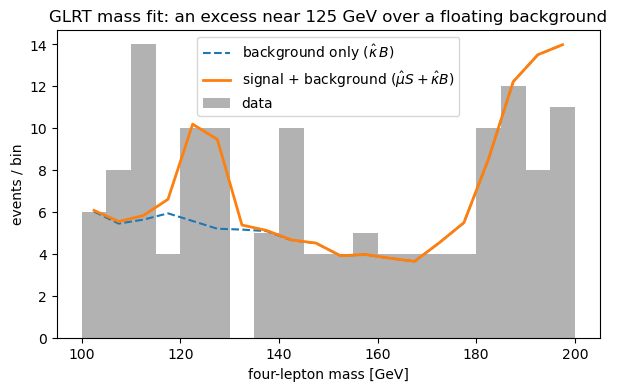

In [8]:
S, B, obs = H._templates(st)          # mass-only templates and observed counts
g = H.glrt(S, B, obs)
print(f"events in the 100-200 GeV fit window: {int(obs.sum())} of {len(data)}")
print(f"mu_hat    (signal strength)      = {g['mu_hat']:.3f}")
print(f"kappa_hat (background scale)      = {g['kappa_hat']:.3f}")
print(f"test statistic q                 = {g['q']:.3f}")
print(f"asymptotic significance sqrt(q)   = {g['Z_asymptotic']:.2f} sigma")

edges = np.linspace(H.MASS_LO, H.MASS_HI, H.N_BINS + 1)
ctr = 0.5*(edges[:-1] + edges[1:])
plt.bar(ctr, obs, width=np.diff(edges), alpha=0.3, label="data", color="k")
plt.plot(ctr, g['kappa_hat']*B, "--", label=r"background only ($\hat\kappa\,B$)")
plt.plot(ctr, g['mu_hat']*S + g['kappa_hat']*B, "-", lw=2,
         label=r"signal + background ($\hat\mu S+\hat\kappa B$)")
plt.xlabel("four-lepton mass [GeV]"); plt.ylabel("events / bin"); plt.legend()
plt.title("GLRT mass fit: an excess near 125 GeV over a floating background")
plt.show()


The asymptotic $\sqrt{q}$ is an approximation, and $\mu = 0$ sits on the
boundary of the parameter space. The p-value that settles it comes from toys,
the Module 4 move: simulate background-only pseudo-datasets, refit each one,
and count how often $q$ reaches the observed value.


In [9]:
tp = H.toy_pvalue(S, B, obs, n_toys=10000, seed=SEED)
print(f"toy-based p-value = {tp['p_value']:.4f}  (+/- {np.sqrt(tp['p_value']*(1-tp['p_value'])/10000):.4f} MC)")
print(f"significance      = {tp['Z_toy']:.2f} sigma  (one-sided)")


toy-based p-value = 0.0111  (+/- 0.0010 MC)
significance      = 2.29 sigma  (one-sided)


## 5. How solid is this? Goodness-of-fit and systematics

A p-value is only as trustworthy as the model behind it. Our $\kappa$ absorbs
the background normalization, but it cannot absorb an error in the background
shape, so the 2.3 sigma above is conditional on the simulated mass shape being
right. Three checks follow: a goodness-of-fit test on the background-only
model, a refit with the shape freed by one tilt parameter, and confidence
intervals for $\mu$ under each assumption.

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

Which check hurts the result most? Write it down, then run.


In [10]:
# (a) Does the background-only model even fit the data?
gof_null = H.goodness_of_fit(g["kappa_null"]*B, obs, n_params=1)
gof_sb   = H.goodness_of_fit(g["mu_hat"]*S + g["kappa_hat"]*B, obs, n_params=2)
print(f"background-only goodness-of-fit p = {gof_null['p_value']:.3f}")
print(f"signal+background   goodness-of-fit p = {gof_sb['p_value']:.3f}")

# (b) Let the background SHAPE flex by one tilt parameter, then re-test:
gs = H.glrt_shape(S, B, obs)
print(f"\nwith a background-shape nuisance:  mu_hat = {gs['mu_hat']:.2f}, "
      f"significance = {gs['Z_asymptotic']:.2f} sigma  (was {g['Z_asymptotic']:.2f})")

# (c) How well is the signal strength pinned down?  Two intervals, because the
#     answer depends entirely on whether the background SHAPE is held fixed.
ci  = H.mu_confidence_interval(S, B, obs)         # kappa profiled, shape FIXED
cis = H.mu_confidence_interval_shape(S, B, obs)   # kappa AND tilt profiled
print(f"\nmu 95% CI, background shape fixed  = [{ci['lo']:.2f}, {ci['hi']:.2f}]")
print(f"mu 95% CI, background shape flexed = [{cis['lo']:.2f}, {cis['hi']:.2f}]"
      f"   <- reaches mu = 0")


background-only goodness-of-fit p = 0.013
signal+background   goodness-of-fit p = 0.036

with a background-shape nuisance:  mu_hat = 0.76, significance = 1.42 sigma  (was 2.29)

mu 95% CI, background shape fixed  = [0.14, 2.35]
mu 95% CI, background shape flexed = [0.00, 2.04]   <- reaches mu = 0


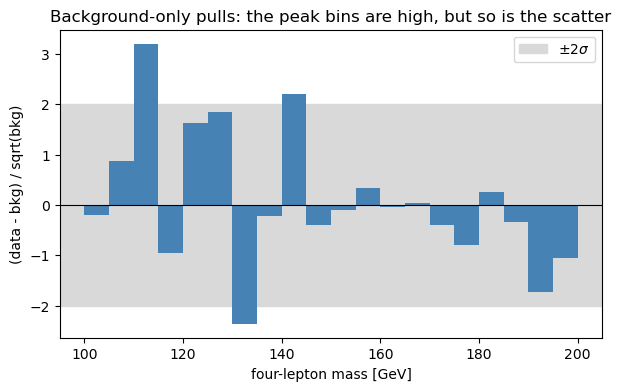

In [11]:
# residual "pulls" per bin show where the background-only fit misses
pull = (obs - g["kappa_null"]*B) / np.sqrt(np.maximum(g["kappa_null"]*B, 1e-9))
plt.axhspan(-2, 2, color="0.85", label=r"$\pm2\sigma$")
plt.bar(ctr, pull, width=np.diff(edges), color="steelblue")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("four-lepton mass [GeV]"); plt.ylabel("(data - bkg) / sqrt(bkg)")
plt.title("Background-only pulls: the peak bins are high, but so is the scatter")
plt.legend(); plt.show()


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

The background-only fit is poor (GOF p of about 0.01), and one tilt parameter
drops the significance from 2.3 to 1.4 sigma. The intervals flip with the same
switch: with the shape held fixed, the 95 percent interval is [0.14, 2.35] and
excludes zero; with the shape free it becomes [0.00, 2.04] and does not. The
exclusion of $\mu = 0$ belongs to the assumption, not to the data, so quote the
fixed-shape interval only with that label on it. And none of this yet counts
the two processes we never modeled (Section 1).

So which numbers do you report? Section 6 puts them together.


## 6. A hint, not a discovery

$\hat\mu \approx 1.1$ is consistent with the Standard Model value of 1, but
consistency is cheap here: the fixed-shape interval allows anything from a
small signal to twice the SM rate, and the shape-free interval allows no
signal at all. The significance is 2.3 sigma under the baseline model and 1.4
once the shape can flex. Even an ordinary $\alpha = 0.05$ decision flips
between those two, since $p \approx 0.01$ rejects and $p \approx 0.08$ does
not. Which background model you are willing to defend decides the verdict, and
that is with the particle-physics bars still far away: 3 sigma to call
something evidence, 5 sigma to call it a discovery.

Verdict: an excess worth watching. Not evidence, not a discovery. That is a
statement about how much information 500 events carry, and about how much of
the answer is coming from the simulation rather than the data.

History agrees. The 2012 announcement did not come from this channel alone;
each experiment reached 5 sigma by combining three decay channels, and the
four-lepton channel crossed 5 sigma on its own only with the full dataset,
roughly twice the sample you are holding. A hint here is what the record says
to expect.


## 7. Power: how much data would a discovery take?

This is the power calculation of Unit 2, run with the same GLRT. Hold the
physics at $\mu = 1$ and scale every expected count by $N$: the median
expected significance grows like $\sqrt N$, and the probability of actually
reaching 5 sigma is $\Phi(Z_\text{median} - 5)$. A median at 5 sigma is only
even odds.

Two assumptions ride along. The expected counts stand in for the median
experiment, an asymptotic step, and the background shape is held at the MC
prediction. Both flatter the projection: with the Section 5 tilt free, 5 times
the data gives a median near 4.7 sigma and power near 0.39, weaker than the
table below will claim.

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

How many multiples of this dataset until the median crosses 5 sigma?
Write down your multiple, then run.


 lumi  median Z   P(reach 5 sigma)
   1x      2.31               0.00
   2x      3.27               0.04
   4x      4.62               0.35
   5x      5.16               0.57
   6x      5.66               0.74
   8x      6.53               0.94
  10x      7.30               0.99


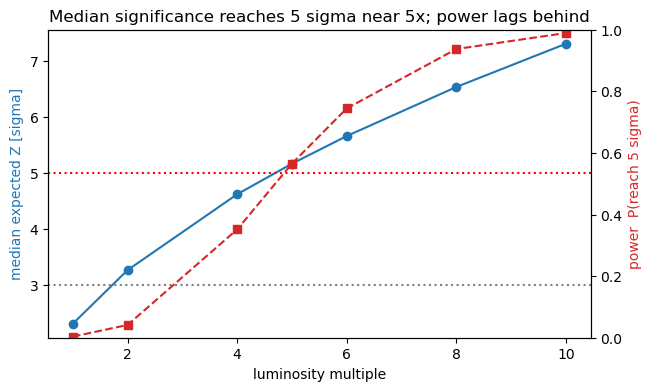

In [12]:
proj = H.glrt_projection(st, factors=(1, 2, 4, 5, 6, 8, 10))
print(f"{'lumi':>5} {'median Z':>9} {'P(reach 5 sigma)':>18}")
for N, z_med, power in proj:
    print(f"{N:>4}x {z_med:9.2f} {power:18.2f}")

fac = [p[0] for p in proj]
fig, ax1 = plt.subplots()
ax1.plot(fac, [p[1] for p in proj], "o-", color="C0")
ax1.axhline(5, ls=":", color="r"); ax1.axhline(3, ls=":", color="gray")
ax1.set_xlabel("luminosity multiple"); ax1.set_ylabel("median expected Z [sigma]", color="C0")
ax2 = ax1.twinx()
ax2.plot(fac, [p[2] for p in proj], "s--", color="C3")
ax2.set_ylabel("power  P(reach 5 sigma)", color="C3"); ax2.set_ylim(0, 1)
plt.title("Median significance reaches 5 sigma near 5x; power lags behind"); plt.show()


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

The median crosses 5 sigma near 5 to 6 times this dataset, but the power there
is only about 55 percent. A confident discovery in this channel alone needs
closer to ten times the data, or a better analysis, or the channel combination
the LHC actually used.

Note what more data does and does not fix. It fixes the counting limit this
table measures. It does not fix a background shape that is subtly wrong, and
Section 5 showed one tilt parameter moving this result from 2.3 to 1.4 sigma;
that error would survive a tenfold luminosity increase untouched. Scaling up an
analysis with a strained background model produces a more significant number,
not a more trustworthy one.

That is the case for more data. Section 8 asks whether a better statistic helps
instead.


## 8. What does the analysis gain from a classifier?

Section 3 left a question standing: the neural net won the AUC comparison by a
wide margin, so it should be the most useful model here. Is it?

Deciding that takes a metric that measures the right thing. Not how well a
score separates simulated signal from simulated background on its own, but how
much the full analysis improves when it uses the score. So we add the score to
the mass fit as a second dimension (a 2D mass-by-score GLRT, the way the LHC
experiments use classifier outputs) and read off the expected significance. It
runs on held-out MC only, never the 495 real events and never the rows a model
trained on, so nothing can rate rows it memorized.

The table also carries two reference rows, and they are the reason this section
is worth your attention. The 2D fit uses 20 mass bins times 4 score bins, so it
has 80 Poisson cells to work with, while the mass-only fit from Section 4 has
20. More cells buy resolution on their own, with no classifier involved, so
the second reference row splits the mass axis into 80 bins and uses no score at
all. The third row is a control: a score built only from the mass,
$h(x) = -|m - 125|$, carrying nothing the fit does not already have.

The third column is a diagnostic. Take the score cut that keeps 80 percent of
signal, and ask what fraction of the background *outside* the 115 to 135 GeV
window survives it. A score that has learned mass throws that background away,
which is what the collapse from 0.50 to 0.03 across the three models shows.
That matters because the sideband is what pins `kappa` down. A hard cut on a
mass-correlated score sculpts the background into the shape of a peak and
destroys the constraint the Section 4 fit relies on, which is why the score
enters as a fit dimension here and never as a cut.

<div style="border-left:3px solid #A6631F;margin:16px 0 8px;padding:2px 0 2px 14px;color:#A6631F;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">Predict</div>

Two predictions before you run the cell. Rank the three classifiers by
expected Z, and say whether any of them beats the 80-cell reference.


In [13]:
baseline20 = H.mass_only_expected_Z(st)
baseline80 = H.matched_baseline_expected_Z(st)       # same cell count as the 2D fit
tag, tagfx = H.mass_tag_scorer()                     # control: mass and nothing else

print(f"{'reference':>26} {'AUC':>7} {'expected Z':>11} {'sideband ret.':>14}")
print(f"{'mass-only, 20 cells':>26} {'':>7} {baseline20:11.2f} {'':>14}")
print(f"{'mass-only, 80 cells':>26} {'':>7} {baseline80:11.2f} {'':>14}   <- fair reference")
r = H.comparison_row(tag, tagfx, st)
print(f"{'mass tag (no new info)':>26} {r['auc']:7.3f} {r['expected_Z']:11.2f} "
      f"{r['sideband_retention']:14.2f}")

print(f"\n{'classifier':>26} {'AUC':>7} {'expected Z':>11} {'sideband ret.':>14}")
for kind, (mdl, fx) in {"linear": (lin, featfn),
                        "quadratic feature exp.": (quad, featfn),
                        "3-layer neural net": (mlp, featfn)}.items():
    r = H.comparison_row(mdl, fx, st)
    print(f"{kind:>26} {r['auc']:7.3f} {r['expected_Z']:11.2f} "
          f"{r['sideband_retention']:14.2f}")


                 reference     AUC  expected Z  sideband ret.
       mass-only, 20 cells                2.35               
       mass-only, 80 cells                2.72                  <- fair reference
    mass tag (no new info)   0.984        2.69           0.00

                classifier     AUC  expected Z  sideband ret.
                    linear   0.632        2.36           0.50


    quadratic feature exp.   0.906        2.71           0.12


        3-layer neural net   0.961        2.42           0.03


<div style="border-left:3px solid #A6631F;background:#FBF2E7;margin:16px 0 8px;padding:6px 8px 6px 14px;color:#8A4E17;font-family:system-ui,-apple-system,sans-serif;font-weight:700;font-size:.72rem;letter-spacing:.11em;text-transform:uppercase;">What you found</div>

Read the table against both predictions.

The classifier ordering is linear 2.36, net 2.42, quadratic 2.71, which does
not match the AUC ordering of linear, quadratic, net. So the first prediction
has the answer Section 3 set up: the best separator is not the most useful
model.

The second prediction is where the section earns its place. No classifier beats
the 80-cell reference of 2.72. The quadratic ties it, and the other two lose to
it. Compared against the 20-cell number, the quadratic looked like a gain of
0.37; compared against a mass-only fit with the same number of cells, it gained
nothing. The control row settles what happened: a score built from the mass and
nothing else scores 2.69, essentially the same as the quadratic. A score that
by construction knows nothing the fit did not already know reproduces almost
the entire apparent improvement.

The sideband column tells the same story from the other side: retention
collapses from 0.50 to 0.03 as the scores learn the mass.

So the improvement was never information. It was resolution. Splitting each
mass bin four ways sharpens the peak against the background, and any score
correlated with mass buys that sharpening whether or not it contributes
anything new. The 20-cell comparison handed the classifiers credit for degrees
of freedom rather than for physics.

This is the trap worth carrying out of the project. A more elaborate model beat
a baseline, the margin looked real, and it dissolved once the baseline was
given the same capacity. Before believing that a model improved on a simpler
one, check what else changed alongside it: bins, parameters, features, tuning
budget. The comparison has to hold those fixed or the number it produces is
measuring the wrong thing.

Two loose ends worth naming rather than hiding. Why the net lands at 2.42 while
the quadratic reaches 2.71 is not settled here, and one candidate is visible in
the code rather than the physics. `sklearn`'s MLP takes no sample weights, so
it is class-balanced by resampling instead: 25,000 draws per class, which is at
most 25,000 of the 62,382 unique background rows, while the other two models
see all of them. The three models are therefore not matched on training data,
which is the same kind of unexamined difference this section was written to
warn about. Naming it is the honest move; measuring it is a separate
experiment. And a real gain would need discrimination decorrelated from mass,
which in this channel means reconstructing the Z pair, particle physics beyond
this course. Building models that are powerful and decorrelated at once is
where the deep learning course picks up.

## 9. What you can, and cannot, claim

Be precise about what the test established. The GLRT compared the data against
a specific background-only model and rejected it at a stated level. That is a
statement about $P_0$: the data are not well described by the simulated
background alone. It is not a statement that the data follow
$\mu S + \kappa B$ with $\mu > 0$.

Which background-only model matters more than it sounds, because this project
fit two of them and they disagree at the 5 percent level. The fixed-shape
baseline gives $p \approx 0.01$ and rejects. The shape-flexible version, the
same background with one tilt free, gives $p \approx 0.08$ and does not. A
rejection is always a rejection of a specified null, and here the
specification is doing much of the work.

Rejecting the null also does not single out the alternative you had in mind. A
small excess near 125 GeV is consistent with a Standard Model Higgs, but the
same rejection could come from a mismodeled simulation (Section 5 showed this
is live), from a process the simulation omits (Section 1 named two), or from
an ordinary fluctuation of a background behaving as simulated. On the last
one, mind the conditional: if $H_0$ is true, rejecting it is a Type I error,
and at $p \approx 0.01$ that happens about once per hundred such analyses.
Whether this rejection is one depends on whether $H_0$ is true, which is what
we do not know.

The floating $\kappa$ protects against an overall normalization error and
certifies nothing else. This is why particle physics does not stop at "the
null is rejected." The 5 sigma bar and the demand for corroboration across
channels and experiments are conventions built to keep lucky fluctuations from
becoming particles. They are strong norms rather than laws of inference, and
they buy no protection against a background model that is simply wrong: a
sufficiently wrong simulation produces a very significant wrong answer. The
remedy for that is a better model and independent corroboration, not a smaller
p-value.

The checkpoint asks you to state, in these terms, what this result does and
does not license. Work through it before entering your numbers below.


## 10. Report your results

Enter these on the submission page. They come from the frozen pipeline above.


In [14]:
results = {
    "mu_hat":                 round(g["mu_hat"], 3),
    "kappa_hat":              round(g["kappa_hat"], 3),
    "glrt_q":                 round(g["q"], 3),
    "toy_p_value":            round(tp["p_value"], 4),
    "significance_baseline":  round(tp["Z_toy"], 2),
    "significance_with_shape":round(gs["Z_asymptotic"], 2),
    "mu_CI_low":              round(ci["lo"], 2),      # background shape FIXED
    "mu_CI_high":             round(ci["hi"], 2),      # background shape FIXED
    "mu_CI_shape_low":        round(cis["lo"], 2),     # background shape FLEXED
    "mu_CI_shape_high":       round(cis["hi"], 2),     # background shape FLEXED
    "background_gof_p":       round(gof_null["p_value"], 3),
    "auc_quadratic":          round(H.auc(quad, featfn, st["holdout"]), 3),
    "baseline_expected_Z":    round(baseline20, 2),
    "matched_baseline_Z":     round(baseline80, 2),
    "lumi_factor_median_5sigma": next(N for N, z, _ in
                                      H.glrt_projection(st, factors=range(1, 13)) if z >= 5),
    "power_at_5x": round(next(p for N, z, p in
                              H.glrt_projection(st, factors=[5])), 2),
}
for k, v in results.items():
    print(f"{k:28s} = {v}")

print("\nmu_CI_high is the fixed-shape bound; with the shape free, the interval reaches mu = 0.")


mu_hat                       = 1.103
kappa_hat                    = 1.298
glrt_q                       = 5.247
toy_p_value                  = 0.0111
significance_baseline        = 2.29
significance_with_shape      = 1.42
mu_CI_low                    = 0.14
mu_CI_high                   = 2.35
mu_CI_shape_low              = 0.0
mu_CI_shape_high             = 2.04
background_gof_p             = 0.013
auc_quadratic                = 0.906
baseline_expected_Z          = 2.35
matched_baseline_Z           = 2.72
lumi_factor_median_5sigma    = 5
power_at_5x                  = 0.57

mu_CI_high is the fixed-shape bound; with the shape free, the interval reaches mu = 0.
